# 02 - Model Regimes: V1 -> V2 -> V3 Validation

The simulator supports three regimes of increasing physical realism:

| Regime | Skin model | Donor | Clearance |
|--------|-----------|-------|-----------|
| **V1** | Homogeneous $D$ | Infinite dose | None |
| **V2** | 3-layer (SC / VE / dermis) with literature $D$ values | Infinite dose | Optional |
| **V3** | 3-layer + spatial heterogeneity | Finite (time-decaying) dose | Optional |

This notebook runs one simulation from each regime and compares:
- Concentration fields and diffusivity maps
- Flux curve shapes ($J(t)$)
- Extracted scalars ($P$, $J_{\text{ss}}$, $T_{\text{lag}}$)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import contextlib, io

from skin_diffusion.notebook_helpers import setup_repo_root
from skin_diffusion.config import load_config
from skin_diffusion.run_utils import run_simulation

repo_root = setup_repo_root()

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
})
print('Setup complete OK')


Setup complete OK


## 1 - Run all three regimes

In [2]:
configs = {
    'V1 - Homogeneous':  'configs/sim/v1_baseline.yaml',
    'V2 - Layered (literature)': 'configs/sim/v2_lidocaine_compare.yaml',
    'V3 - Heterogeneous': 'configs/sim/v3_layers_literature.yaml',
}

runs = {}
for label, cfg_path in configs.items():
    print(f'\n{label}')
    cfg = load_config(cfg_path)
    with contextlib.redirect_stderr(io.StringIO()):        # silence tqdm bars
        C_snap, t_save, D_field, k_field, patch_mask, diag, met, stab = run_simulation(cfg)
    runs[label] = dict(
        cfg=cfg, C_snap=C_snap, t_save=t_save, D_field=D_field,
        patch_mask=patch_mask, diagnostics=diag, metrics=met, stability=stab,
    )
    print(f'  Grid: {C_snap.shape[1]}x{C_snap.shape[2]}, T={cfg.grid.T}s, '
          f'snapshots={C_snap.shape[0]}')
    print(f'  P={met.get("P")}, J_ss={met.get("J_ss")}, Tlag={met.get("Tlag")}')

print('\nAll regimes complete.')



V1 - Homogeneous


  Grid: 64x64, T=1.0s, snapshots=4001
  P=1.4215015597532132, J_ss=1.4215015597532132, Tlag=0.07925173129882605

V2 - Layered (literature)


  Grid: 64x64, T=86400.0s, snapshots=1441
  P=8.053524927875683e-07, J_ss=8.053524927875683e-07, Tlag=6027.880195717288

V3 - Heterogeneous


  Grid: 64x64, T=86400.0s, snapshots=1441
  P=5.137711400050468e-17, J_ss=5.137711400050468e-17, Tlag=None

All regimes complete.


## 2 - Diffusivity fields

V1 has a uniform $D$. V2 shows three distinct layers (stratum corneum at top with low $D$,
dermis at bottom with high $D$). V3 adds correlated spatial heterogeneity on top of the layers.

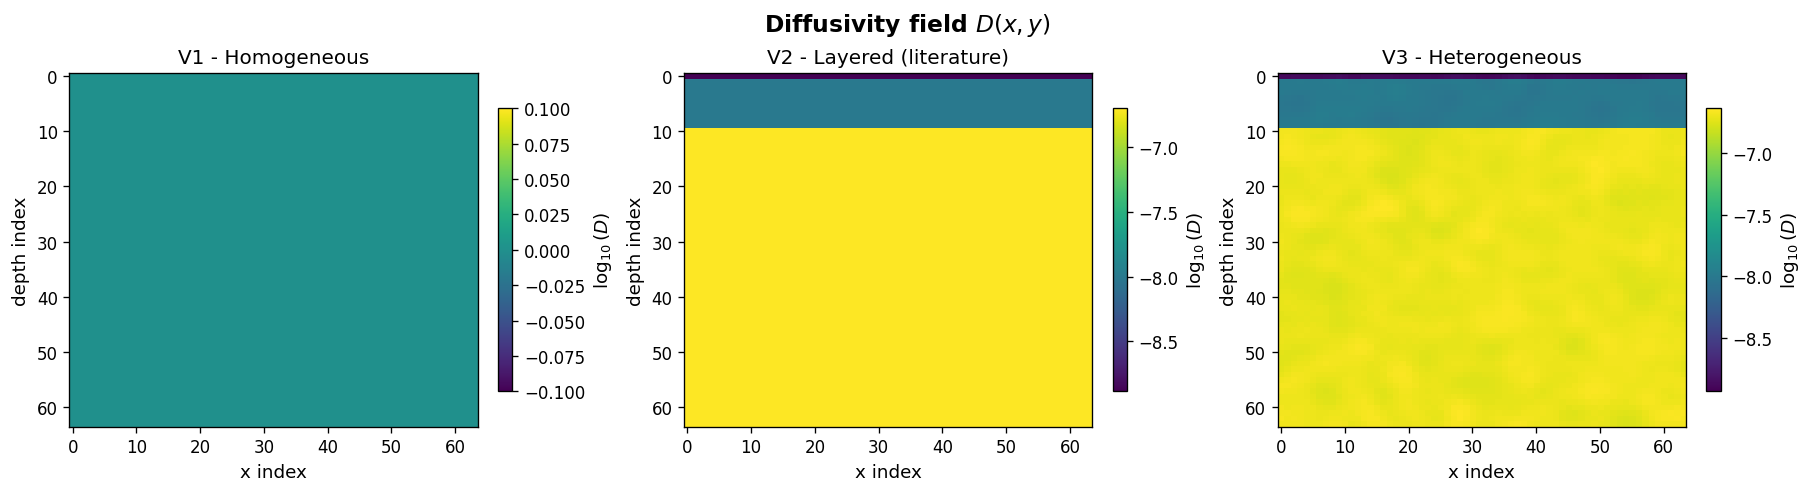

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
fig.suptitle('Diffusivity field $D(x, y)$', fontsize=14, fontweight='bold')

for ax, (label, r) in zip(axes, runs.items()):
    im = ax.imshow(np.log10(r['D_field'] + 1e-30), origin='upper', aspect='auto', cmap='viridis')
    ax.set_title(label)
    ax.set_xlabel('x index')
    ax.set_ylabel('depth index')
    fig.colorbar(im, ax=ax, shrink=0.8, label='$\\log_{10}(D)$')

plt.show()

**Interpretation.**

- **V1** — Spatially uniform $D$ field (single colour throughout the domain).
- **V2** — Three distinct horizontal layers: thin, low-$D$ stratum corneum at the top; mid-$D$ viable epidermis; higher-$D$ dermis below — matching literature values.
- **V3** — Retains the layered structure but adds visible speckled heterogeneity, representing biological variability in tissue diffusivity.

## 3 - Final concentration snapshots

The final frame of each simulation shows how drug distribution differs with model complexity.

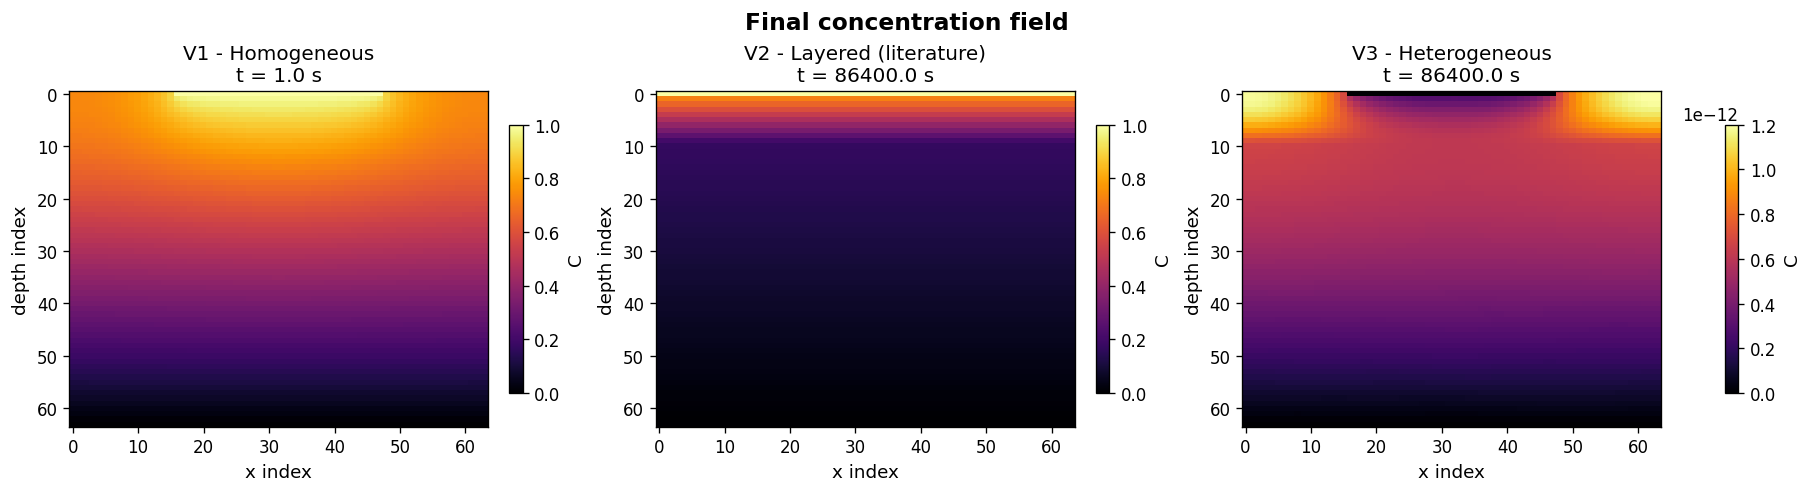

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
fig.suptitle('Final concentration field', fontsize=14, fontweight='bold')

for ax, (label, r) in zip(axes, runs.items()):
    frame = r['C_snap'][-1]
    im = ax.imshow(frame, origin='upper', aspect='auto', cmap='inferno')
    ax.set_title(f"{label}\nt = {r['t_save'][-1]:.1f} s")
    ax.set_xlabel('x index')
    ax.set_ylabel('depth index')
    fig.colorbar(im, ax=ax, shrink=0.8, label='C')

plt.show()

**Interpretation.**

- **V1** — Concentration front has propagated roughly halfway through the domain by $t = 1$ s, consistent with fast uniform diffusion.
- **V2** — At $t = 86\,400$ s, drug is mostly trapped in the upper layers — the low-$D$ stratum corneum acts as the primary barrier.
- **V3** — At $t = 86\,400$ s, more spatially variable penetration due to heterogeneous $D$ and the decaying donor, with lower overall concentration than V1.

## 4 - Flux curves compared

The shape of $J(t)$ changes dramatically across regimes:
- **V1** shows classic diffusion rise to steady state
- **V2** exhibits a delayed onset due to the high-resistance SC layer
- **V3** peaks and decays because of the finite (time-decaying) donor

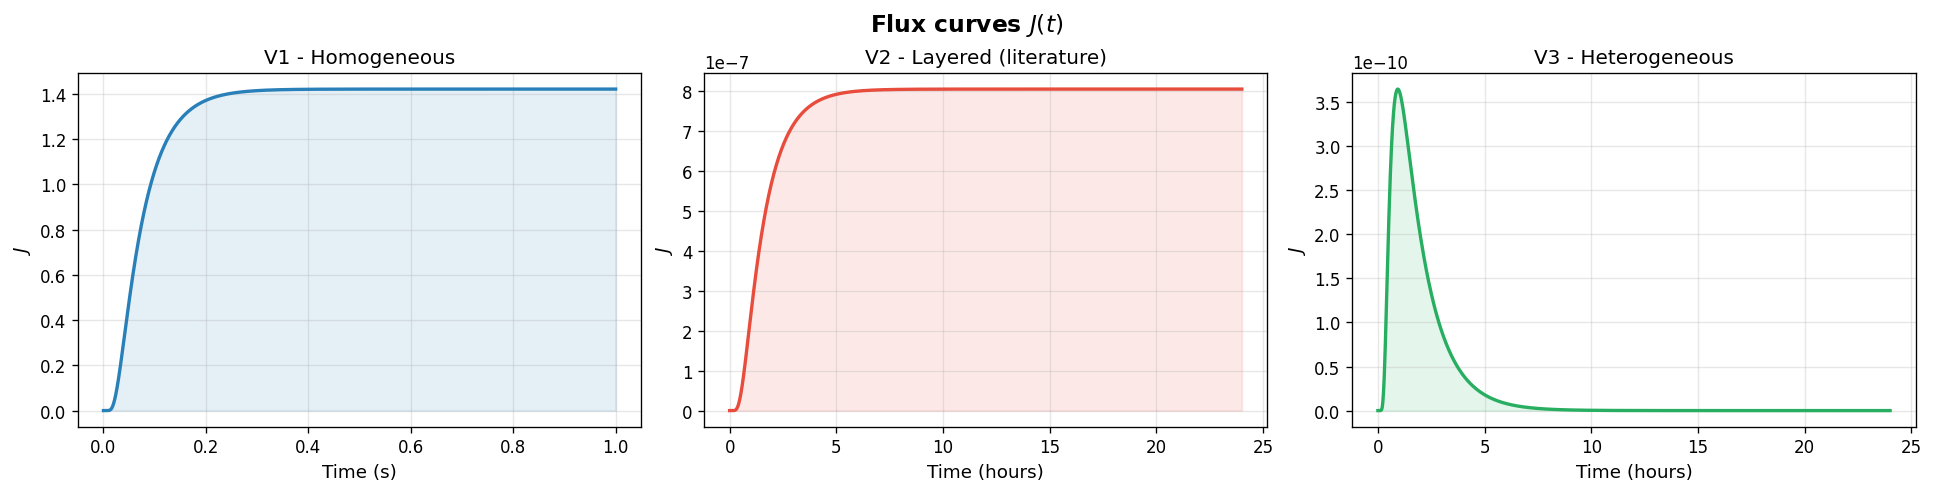

In [5]:
colours = ['#2980b9', '#e74c3c', '#27ae60']

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
fig.suptitle('Flux curves $J(t)$', fontsize=14, fontweight='bold')

for ax, (label, r), c in zip(axes, runs.items(), colours):
    J = np.array(r['metrics']['J'], dtype=float)
    t = np.array(r['metrics']['t'], dtype=float)
    # Normalise time to hours for V2/V3 (long runs), seconds for V1
    if r['cfg'].grid.T > 100:
        t_plot = t / 3600.0
        xlabel = 'Time (hours)'
    else:
        t_plot = t
        xlabel = 'Time (s)'
    ax.plot(t_plot, J, lw=2, color=c)
    ax.fill_between(t_plot, 0, J, alpha=0.12, color=c)
    ax.set_title(label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('$J$')
    ax.grid(alpha=0.3)

plt.show()

**Interpretation.**

- **V1** — Flux rises monotonically toward steady state within 1 s — the classic constant-source diffusion profile.
- **V2** — Delayed onset ($T_\text{lag} \approx 6\,028$ s) before slowly approaching a very low steady-state flux ($J_\text{ss} \approx 8 \times 10^{-7}$), reflecting the high SC barrier resistance.
- **V3** — Peaks and then decays because the time-decaying donor depletes the source concentration — this regime most closely mimics real topical drug delivery.

## 5 - Scalar comparison table

In [6]:
print(f'{"Regime":<28s} {"P (cm/s)":>14s} {"J_ss":>14s} {"T_lag (s)":>14s}')
print('-' * 72)
for label, r in runs.items():
    m = r['metrics']
    P = m.get('P')
    J_ss = m.get('J_ss')
    Tlag = m.get('Tlag')
    P_str = f'{P:.4e}' if P is not None else '--'
    J_str = f'{J_ss:.4e}' if J_ss is not None else '--'
    T_str = f'{Tlag:.1f}' if Tlag is not None else '--'
    print(f'{label:<28s} {P_str:>14s} {J_str:>14s} {T_str:>14s}')

Regime                             P (cm/s)           J_ss      T_lag (s)
------------------------------------------------------------------------
V1 - Homogeneous                 1.4215e+00     1.4215e+00            0.1
V2 - Layered (literature)        8.0535e-07     8.0535e-07         6027.9
V3 - Heterogeneous               5.1377e-17     5.1377e-17             --


**Interpretation.**

- **V1** — Permeability $P = 1.42$ and steady-state flux are numerically equal because the simple geometry has unit donor concentration and thickness.
- **V2** — Permeability drops by six orders of magnitude ($8.1 \times 10^{-7}$) — the layered SC dominates transport resistance; lag time ≈ 6 028 s (~1.7 h).
- **V3** — Reports extremely small $P$ and no $T_\text{lag}$ because the decaying donor prevents a true steady state from forming.

---

### Take-aways

- Adding **layered structure** (V2) dramatically increases lag time and reduces permeability --
  consistent with the SC barrier dominating skin transport.
- **Spatial heterogeneity + finite dose** (V3) produces peaked, decaying flux curves that better
  represent real topical applications.
- The V3 regime is used for all ML/PINN dataset generation.

**Next notebook ->** Grid-convergence analysis and 1-D analytic benchmark.